In [25]:
#Tracker Data Analysis
import scipy.ndimage
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100
plt.rcParams.update({'font.size':12, 'font.family':'serif'}) #Setting fonts
plt.rcParams['text.usetex'] = False

import string #For figure labels

def plotderive(file, n=0, m=-1):
    t = []
    y = []
    for i in file:
        t.append(i[0])
        y.append(i[2])
    
    yfull = y - y[0]
    y = np.array(yfull[n:m])
    t = np.array(t[n:m])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.scatter(t, y, c='firebrick', label='Data', s=10)
    m,c = np.polyfit(t, y, deg=1)
    y_fit = m*t + c
    eqn_y = f"$y = {m:.3f}t + {c:.3f}$"
    ax1.plot(t, y_fit, c='darkblue', label=eqn_y)
    
    ax1.grid()
    ax1.legend()
    ax1.set_xlabel("time (s)")
    ax1.set_ylabel(r"y ($m$)")
    
    v_fit = np.repeat(m, len(t)) 
    eqn_v = f"$V = {m:.3f}t$"
    ax2.scatter(t, v_fit, c='darkblue', label=eqn_v, s=10)
    
    ax2.grid()
    ax2.set_xlabel("time (s)")
    ax2.set_ylabel(r"V ($ms^{-1}$)")
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

def plot_all_trials_derive_simple(base_path, prefix, num_trials=16, n=0, m=-1):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    cmap = plt.cm.get_cmap('tab20', num_trials)
    colors = [cmap(i % cmap.N) for i in range(num_trials)]

    g_values = []

    for i in range(1, num_trials + 1):
        filepath = os.path.join(base_path, f"{prefix}{i}.txt")
        try:
            data = np.loadtxt(filepath, delimiter=',', skiprows=2)
            if data.ndim < 2 or data.shape[1] < 3:
                print(f"Skipping Trial {i}: insufficient data")
                continue

            t = data[:, 0]
            y = data[:, 2]
            y = y - y[0]

            t = np.array(t[n:m])
            y = np.array(y[n:m])

            if len(t) < 5 or np.any(np.isnan(t)) or np.any(np.isnan(y)):
                print(f"Skipping Trial {i}: invalid slice")
                continue

            a, b, c = np.polyfit(t, y, deg=2)
            y_fit = a * t**2 + b * t + c
            v_fit = 2 * a * t + b

            eqn_y = f"$y = {a:.3f}t^2 + {b:.3f}t + {c:.3f}$"
            eqn_v = f"$V = {2*a:.3f}t + {b:.3f}$"

            color = colors[i - 1]

            # Position plot
            ax1.scatter(t, y, s=20, color=color, alpha=0.7)
            ax1.plot(t, y_fit, lw=1.5, color=color, label=f"Trial {i}")

            # Velocity plot
            ax2.scatter(t, v_fit, s=20, color=color, alpha=0.7)
            ax2.plot(t, v_fit, lw=1.5, color=color, label=f"Trial {i}")

            g_values.append(2 * a)

        except Exception as e:
            print(f"Skipping Trial {i}: {e}")

    # Formatting
    ax1.set_xlabel("time (s)")
    ax1.set_ylabel(r"y ($m$)")
    ax1.set_title("Position vs Time — All Trials")
    ax1.grid()
    ax1.legend(fontsize=8, loc="best", ncol=2)

    ax2.set_xlabel("time (s)")
    ax2.set_ylabel(r"V ($ms^{-1}$)")
    ax2.set_title("Velocity vs Time — Derived from Fit")
    ax2.grid()
    ax2.legend(fontsize=8, loc="best", ncol=2)

    plt.tight_layout()
    plt.show()

    # Summary of g values
    if g_values:
        mean_g = np.mean(g_values)
        std_g = np.std(g_values)
        print("\n--- Gravitational Acceleration Results ---")
        for i, g in enumerate(g_values, 1):
            print(f"Trial {i:2d}: g = {g:6.4f} m/s²")
        print(f"\nMean g = {mean_g:.4f} ± {std_g:.4f} m/s² (std)")
    else:
        print("No valid g values computed.")


# Mass 1

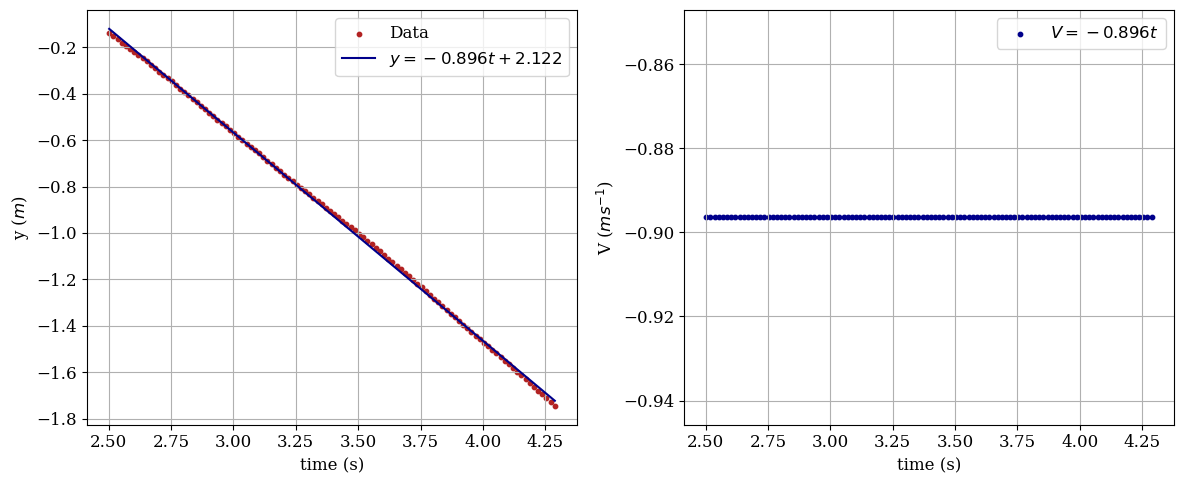

In [3]:
#TRIAL 1
file_t1 = np.loadtxt("../Freefall_PartB/B_nomass.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t1, 150)

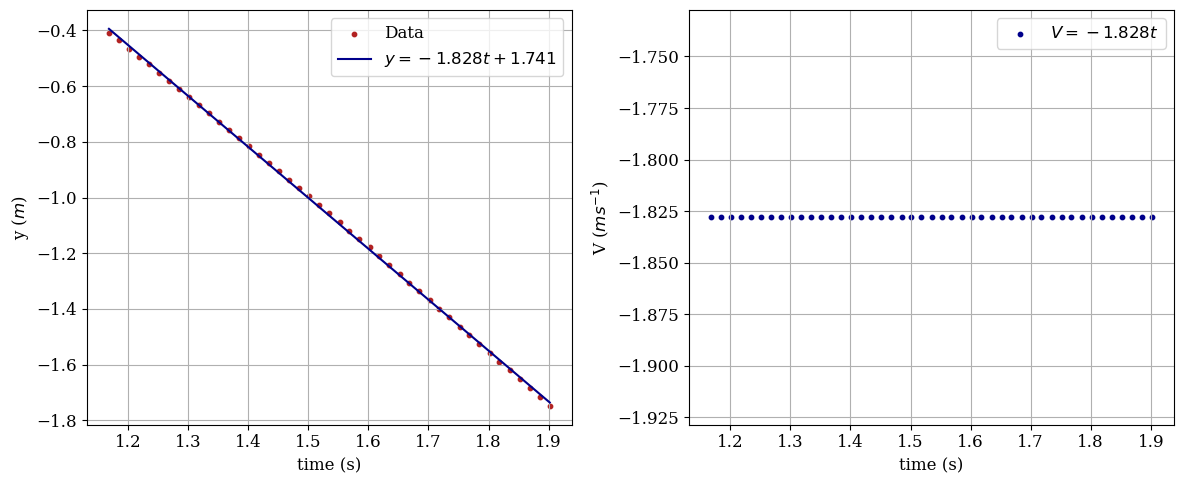

In [4]:
#TRIAL 2
file_t2 = np.loadtxt("../Freefall_PartB/B_inc_1.txt", delimiter=',', skiprows=2)
# print(file)
plotderive(file_t2, 70)

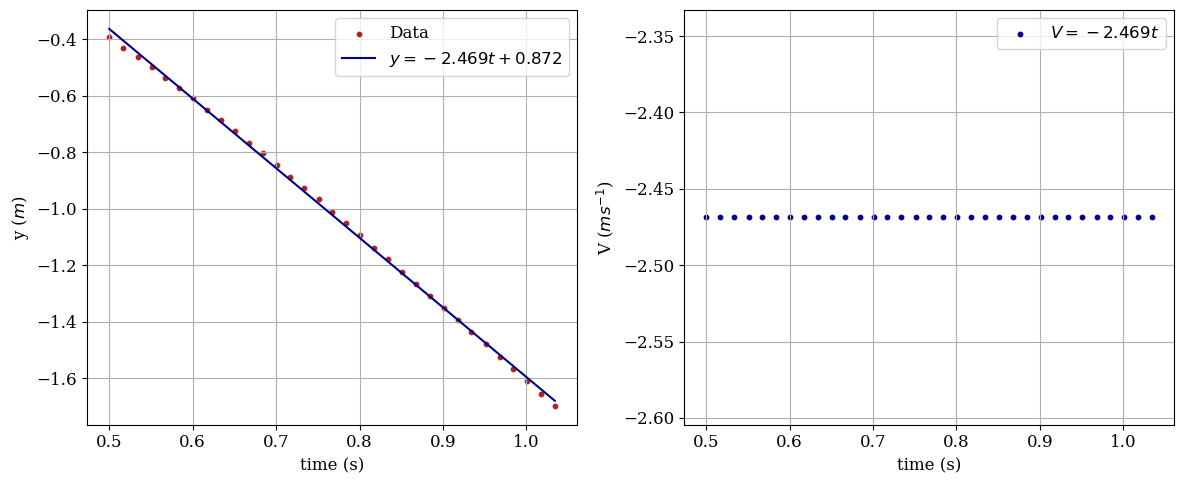

In [5]:
#TRIAL 3
file_t3 = np.loadtxt("../Freefall_PartB/B_inc_2.txt", delimiter=',', skiprows=2)
# print(file)
plotderive(file_t3, 30)

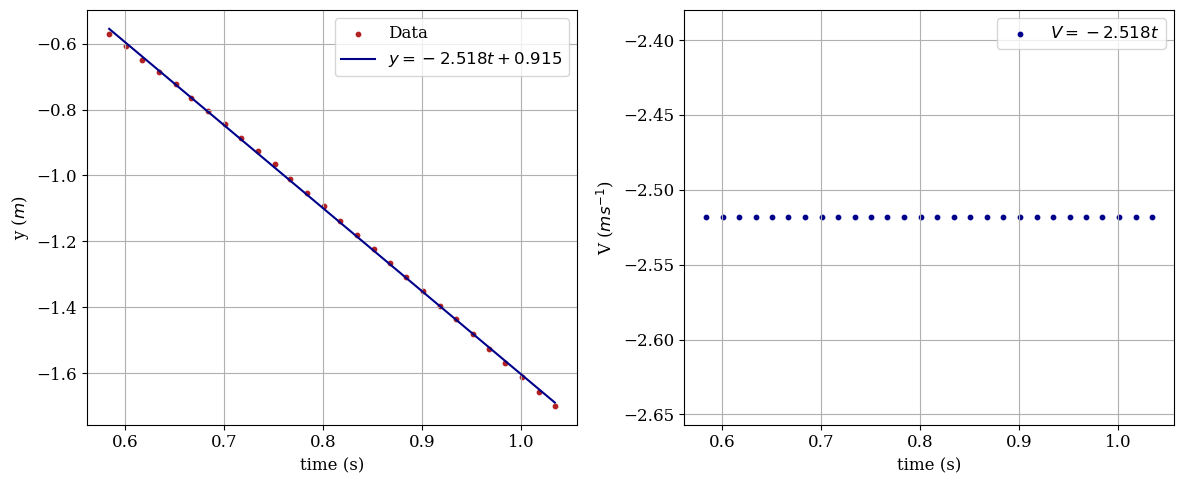

In [6]:
#TRIAL 4
file_t4 = np.loadtxt("../Freefall_PartB/B_inc_3.txt", delimiter=',', skiprows=2)
# print(file)
plotderive(file_t3, 35)

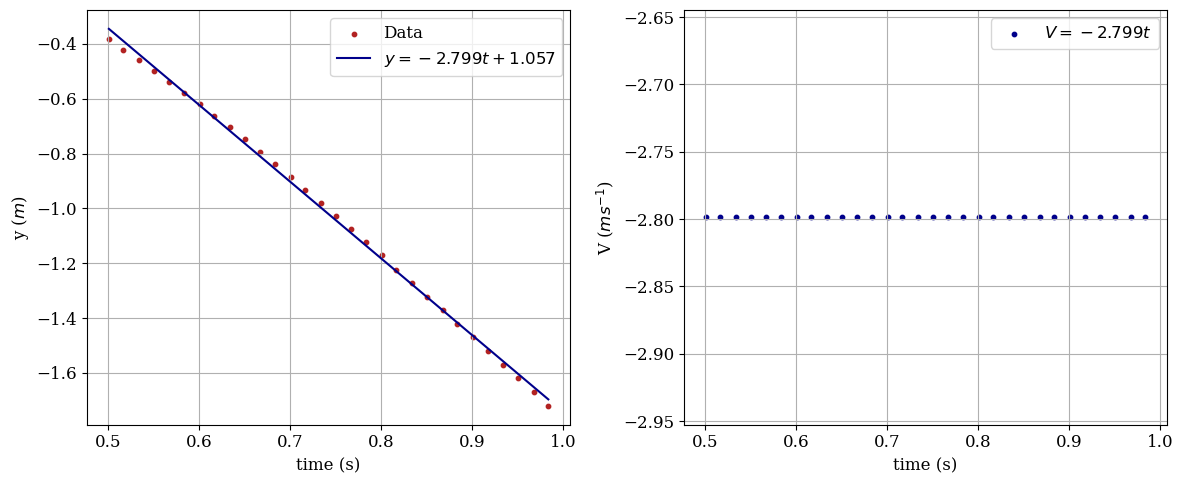

In [7]:
#TRIAL 5
file_t5 = np.loadtxt("../Freefall_PartB/B_inc_4.txt", delimiter=',', skiprows=2)
#print(file)
plotderive(file_t4, 30)

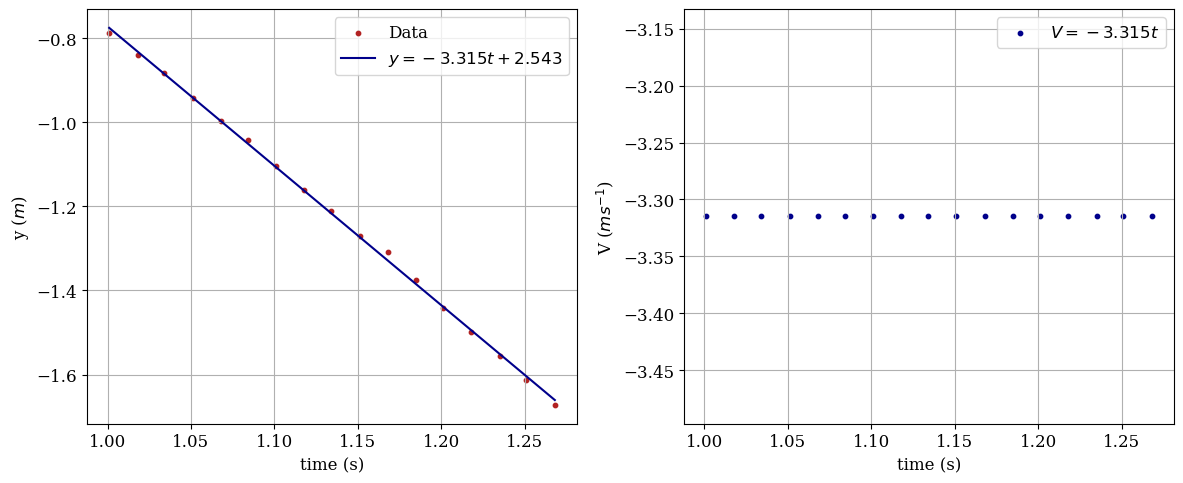

In [8]:
#TRIAL 6
file_t6 = np.loadtxt("../Freefall_PartB/B_inc_5.txt", delimiter=',', skiprows=2)
#print(file)
plotderive(file_t6,60)

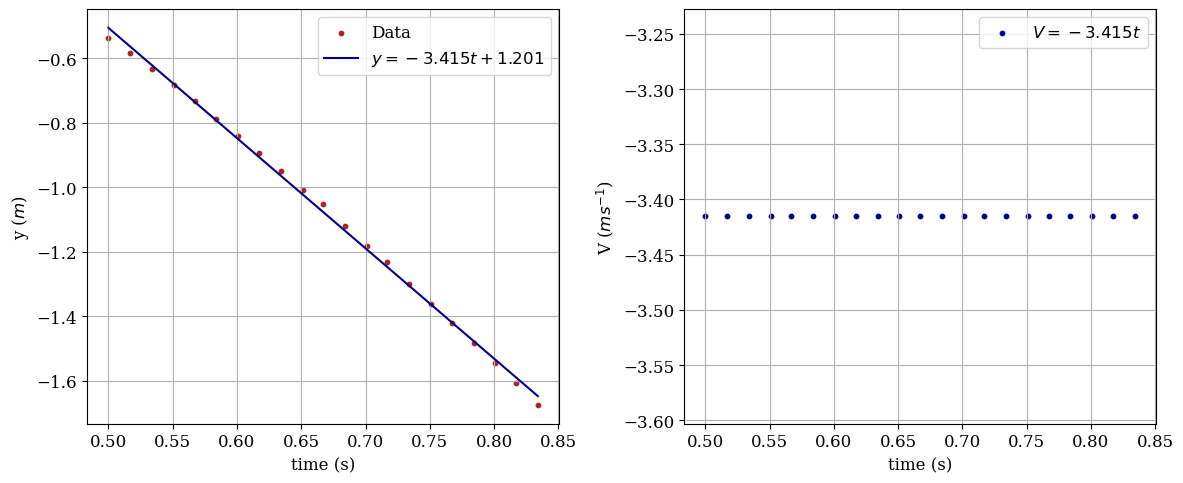

In [9]:
#TRIAL 7
file_t7 = np.loadtxt("../Freefall_PartB/B_inc_6.txt", delimiter=',', skiprows=2)
#print(file)
plotderive(file_t7, 30)

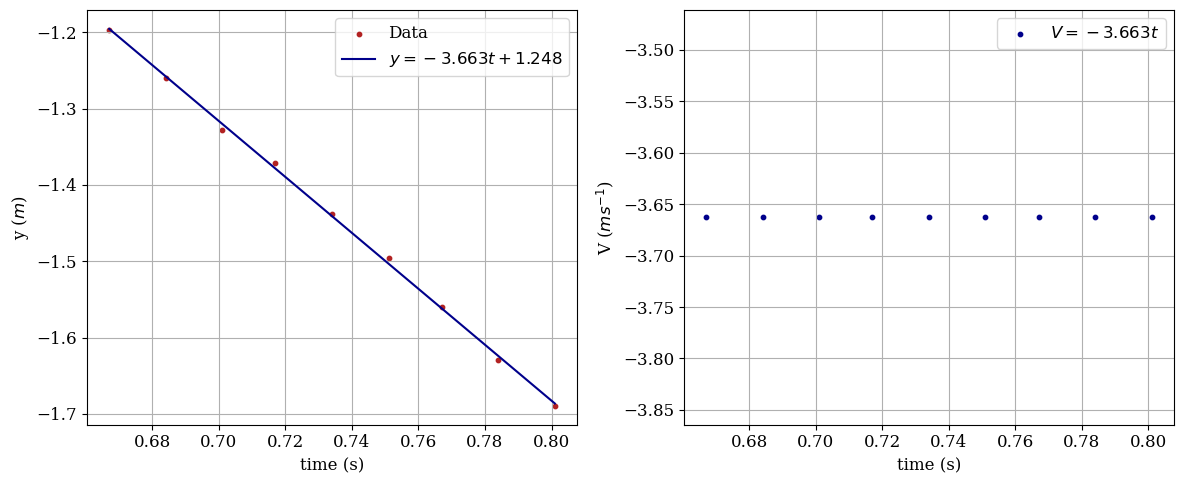

In [10]:
#TRIAL 8
file_t8 = np.loadtxt("../Freefall_PartB/B_inc_7.txt", delimiter=',', skiprows=2)
#print(file)
plotderive(file_t8, 40)

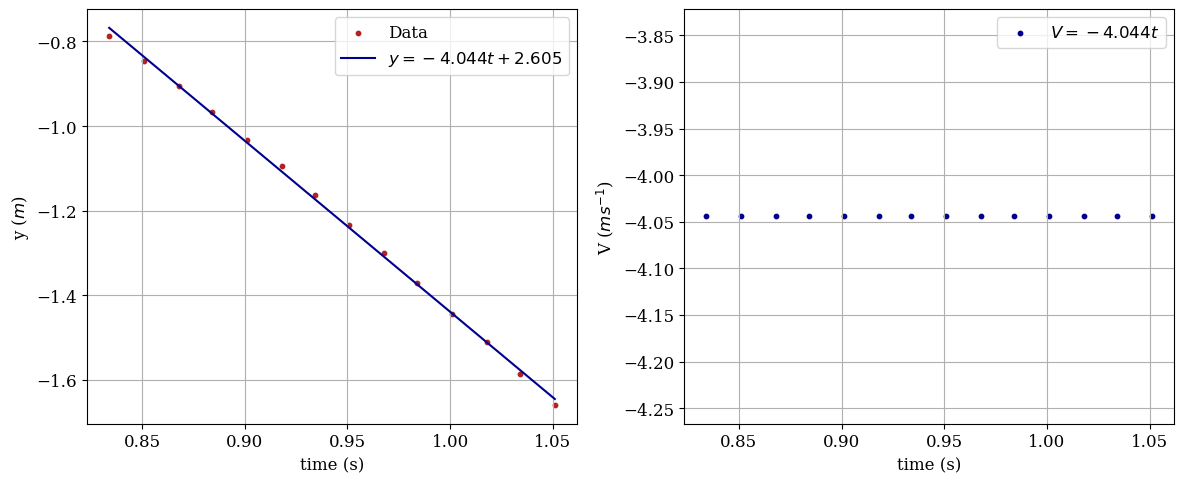

In [11]:
#TRIAL 9
file_t9 = np.loadtxt("../Freefall_PartB/B_inc_8.txt", delimiter=',', skiprows=2)
#print(file)
plotderive(file_t9, 50)

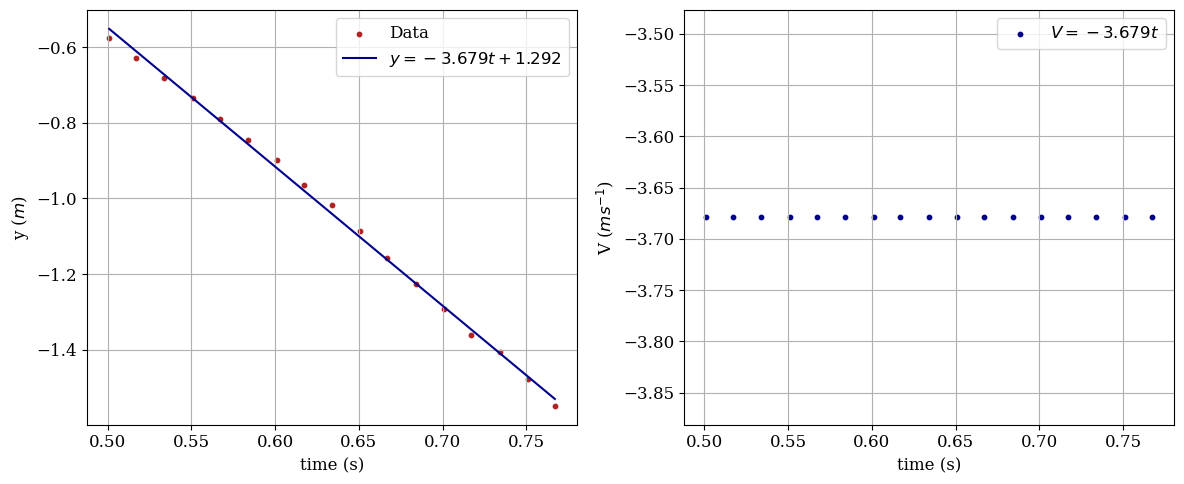

In [12]:
#TRIAL 10
file_t10 = np.loadtxt("../Freefall_PartB/B_inc_9.txt", delimiter=',', skiprows=2)
#print(file)
plotderive(file_t10, 30, -2)

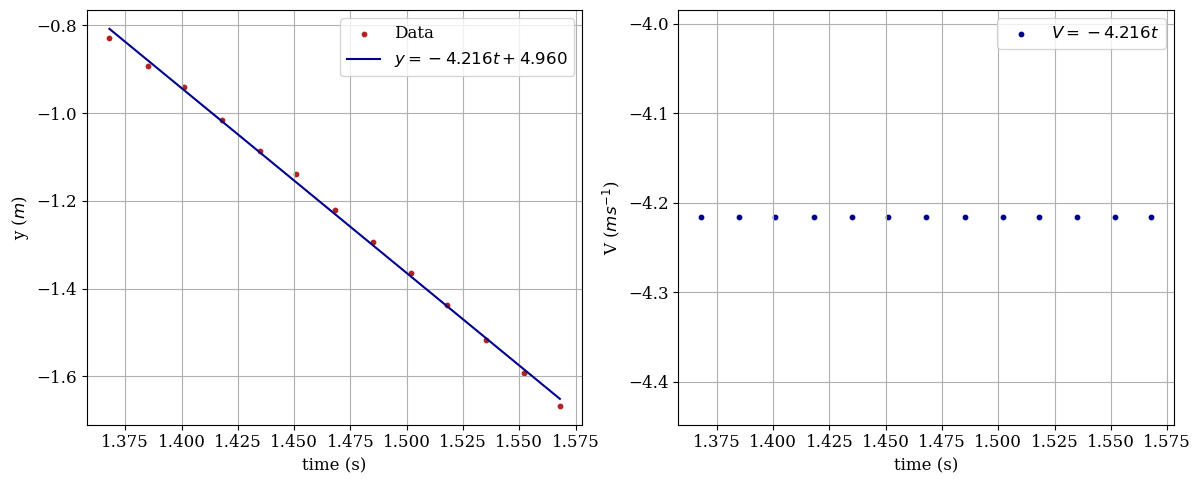

In [13]:
#TRIAL 11
file_t11 = np.loadtxt("../Freefall_PartB/B_inc_10.txt", delimiter=',', skiprows=2)
#print(file)
plotderive(file_t11, 82)

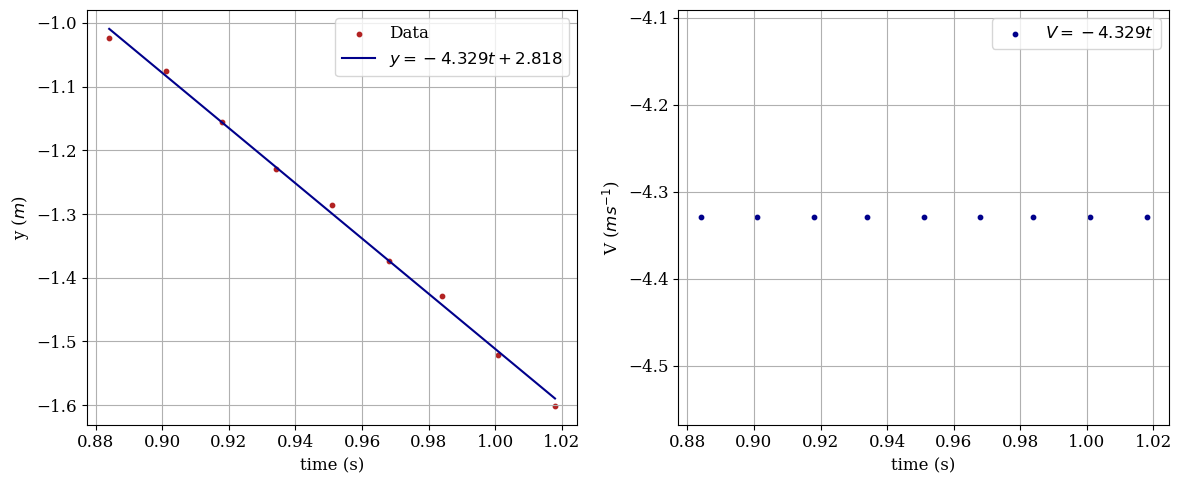

In [14]:
#TRIAL 12
file_t12 = np.loadtxt("../Freefall_PartB/B_inc_11.txt", delimiter=',', skiprows=2)
#print(file)
plotderive(file_t12, 53)

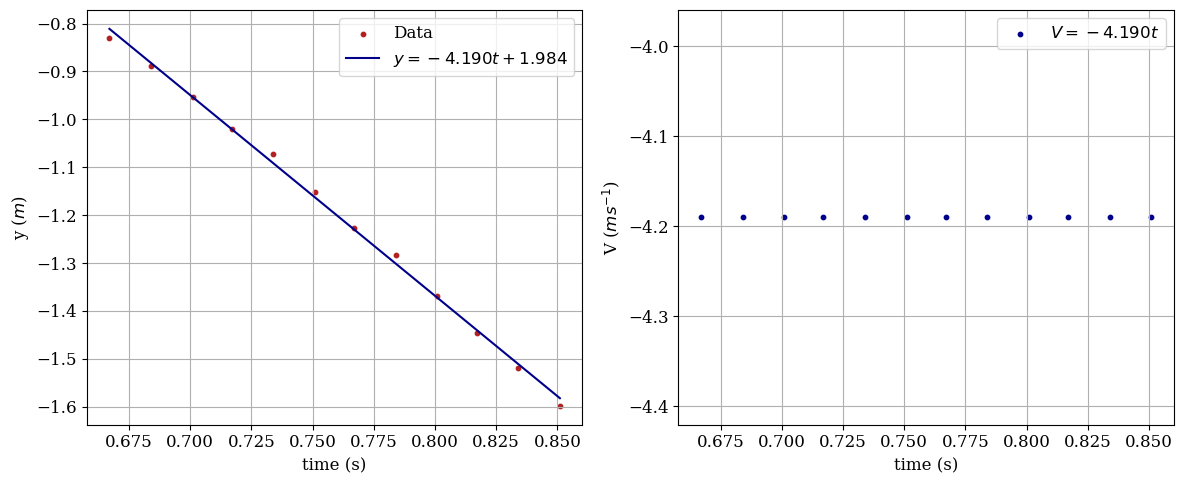

In [15]:
#TRIAL 13
file_t13 = np.loadtxt("../Freefall_PartB/B_inc_12.txt", delimiter=',', skiprows=2)
#print(file)
plotderive(file_t13, 40)

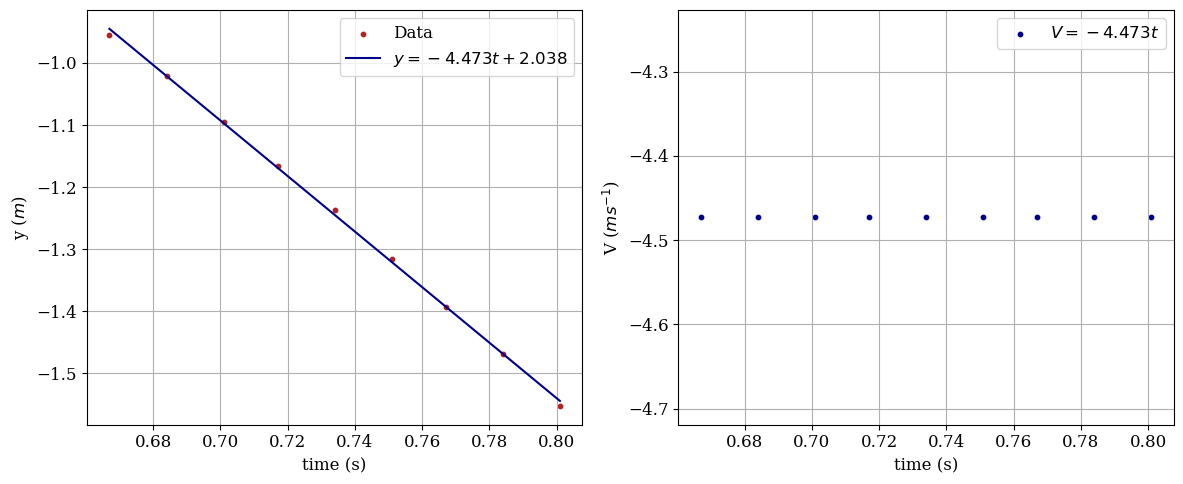

In [16]:
#TRIAL 14
file_t14 = np.loadtxt("../Freefall_PartB/B_inc_13.txt", delimiter=',', skiprows=2)
#print(file)
plotderive(file_t14, 40)

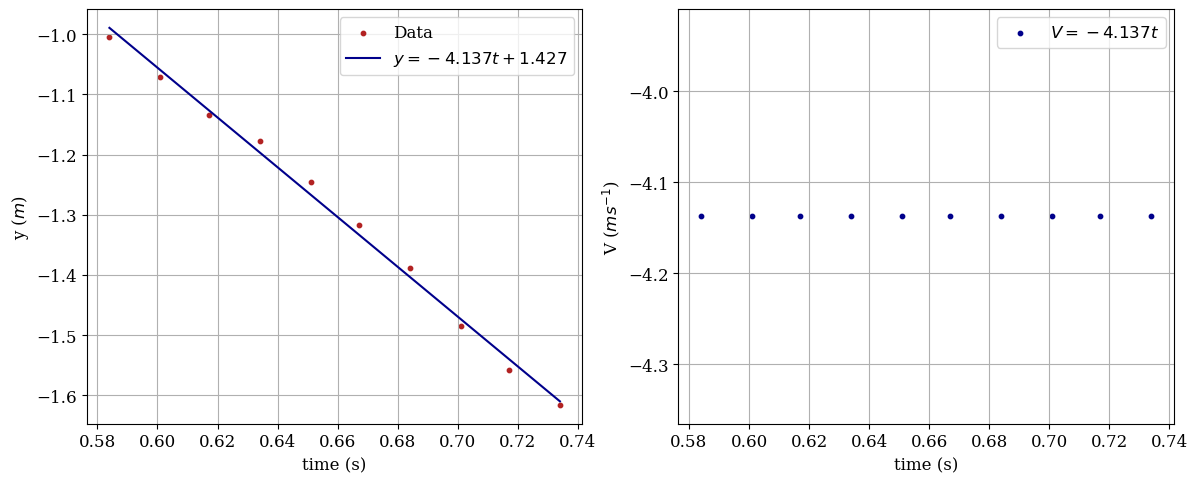

In [17]:
#TRIAL 15
file_t15 = np.loadtxt("../Freefall_PartB/B_inc_14.txt", delimiter=',', skiprows=2)
#print(file)
plotderive(file_t15, 35)

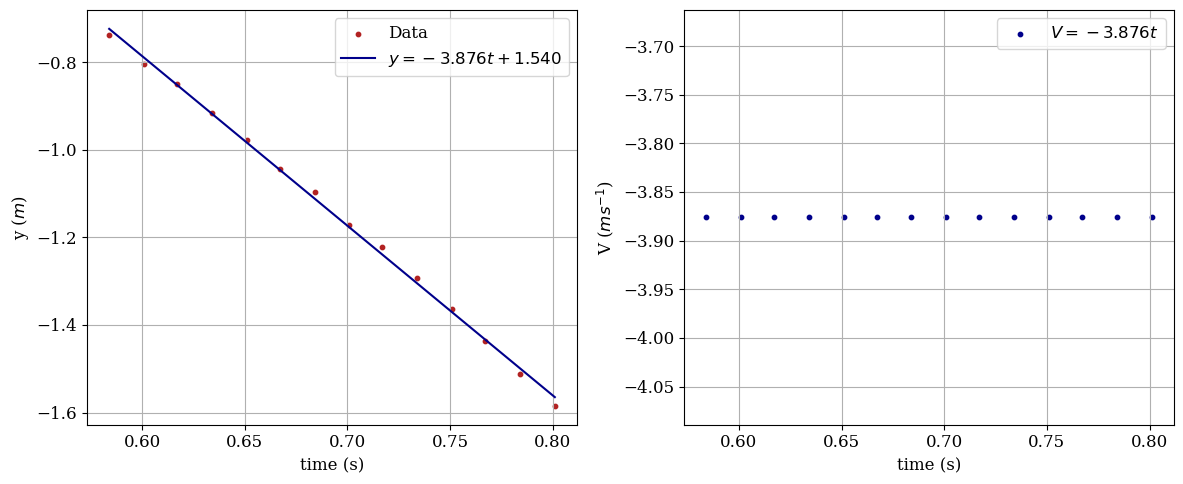

In [18]:
#TRIAL 16
file_t16 = np.loadtxt("../Freefall_PartB/B_inc_15.txt", delimiter=',', skiprows=2)
#print(file)
plotderive(file_t16, 35)

C:\Users\abhim\AppData\Local\Temp\ipykernel_14452\1399118041.py:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', num_trials)


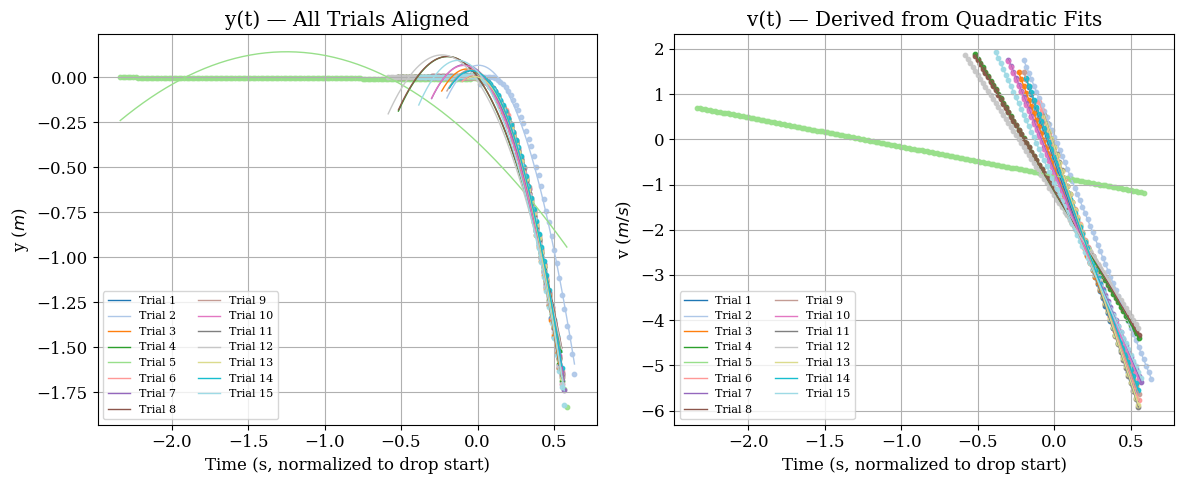


--- Gravitational Acceleration Results ---
Trial  1: g = -9.6892 m/s²
Trial  2: g = -8.4465 m/s²
Trial  3: g = -9.0272 m/s²
Trial  4: g = -5.8797 m/s²
Trial  5: g = -0.6454 m/s²
Trial  6: g = -10.1336 m/s²
Trial  7: g = -8.2098 m/s²
Trial  8: g = -5.7862 m/s²
Trial  9: g = -9.4893 m/s²
Trial 10: g = -8.2770 m/s²
Trial 11: g = -10.4696 m/s²
Trial 12: g = -5.3189 m/s²
Trial 13: g = -10.3755 m/s²
Trial 14: g = -9.3996 m/s²
Trial 15: g = -7.5828 m/s²

Mean g = -7.9154 ± 2.5225 m/s² (std)


In [27]:
g2 = plot_all_trials_derive_normalized("../Freefall_PartA/mass M2/", prefix="m2_trial", num_trials=15)